In [5]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from src.plot_utils import format_axis
RESULTS_ROOT = Path('../../../results/icl_copy_firstlast/runs')


In [6]:
# large 30 seeds and with 0.1 kept fraction during refusal finetuning
GROUP_DIRS = [
    RESULTS_ROOT / "20260410170109_startCopyFirstFrac0.5_endCopyFirstFrac0.5_n30seeds",
    RESULTS_ROOT / "20260410170109_startCopyFirstFrac0.1_endCopyFirstFrac0.5_n30seeds",
]

MIN_ACCURACY = 0.9   # must match the threshold used when running the finetuning


In [7]:
def load_pure_refusal_results(group_dirs, min_accuracy=0.9):
    """
    Returns: refusal_data[frac][refuse_task] = list of result dicts
    where frac = start_copy_first_frac (float).
    Only includes seeds that pass the min_accuracy filter.
    Scans all pure_refusal_* subdirs and reads refuse_task from the result JSON.
    """
    refusal_data = {}

    for group_dir_str in group_dirs:
        group_dir = Path(group_dir_str)
        if not group_dir.exists():
            print(f'WARNING: {group_dir} does not exist, skipping.')
            continue

        seed_dirs = sorted([d for d in group_dir.iterdir()
                            if d.is_dir() and d.name.startswith('seed_')])

        for seed_dir in seed_dirs:
            # Scan all pure_refusal_* subdirs (handles both pure and mixed naming)
            refusal_dirs = sorted([d for d in seed_dir.iterdir()
                                   if d.is_dir() and d.name.startswith('pure_refusal_')])

            for refusal_dir in refusal_dirs:
                result_file = refusal_dir / 'results.json'
                if not result_file.exists():
                    continue

                with open(result_file) as f:
                    r = json.load(f)

                # Filter by pretrain accuracy
                pm = r.get('pretrain_final_accuracy', {})
                if (pm.get('copy_first_accuracy', 0) < min_accuracy or
                        pm.get('copy_last_accuracy', 0) < min_accuracy):
                    continue

                # Use the canonical refuse_task name from the result JSON
                refuse_task = r['refuse_task']

                frac = r['config'].get('start_copy_first_frac')
                if frac is None:
                    m = re.search(r'startCopyFirstFrac([0-9.]+)', group_dir.name)
                    frac = float(m.group(1)) if m else -1.0

                refusal_data.setdefault(frac, {}).setdefault(refuse_task, []).append(r)

    return refusal_data


refusal_data = load_pure_refusal_results(GROUP_DIRS, MIN_ACCURACY)

for frac in sorted(refusal_data):
    for rt, seeds in refusal_data[frac].items():
        print(f'frac={frac}  refuse_{rt}: {len(seeds)} seeds')

frac=0.1  refuse_copy_first: 30 seeds
frac=0.1  refuse_copy_last: 30 seeds
frac=0.5  refuse_copy_first: 8 seeds
frac=0.5  refuse_copy_last: 8 seeds


In [8]:
def interpolate_to_grid(steps_list, values_list):
    """Interpolate per-seed histories to a common step grid for mean/std."""
    all_steps = sorted(set(s for steps in steps_list for s in steps))
    grid = np.array(all_steps)
    interp_vals = []
    for steps, vals in zip(steps_list, values_list):
        interp_vals.append(np.interp(grid, steps, vals))
    return grid, np.stack(interp_vals)


frac_labels = {
    0.9: 'Copy-first early (start=0.9)',
    0.1: 'Copy-last early (start=0.1)',
    0.5: 'Equal (start=0.5)',
}

refuse_task_colors = {
    'copy_first': '#e74c3c',   # red = refuse copy first
    'copy_last':  '#3498db',   # blue = refuse copy last
}
refuse_task_labels = {
    'copy_first': 'Refuse copy-first',
    'copy_last':  'Refuse copy-last',
}


## Figure 2 of the paper

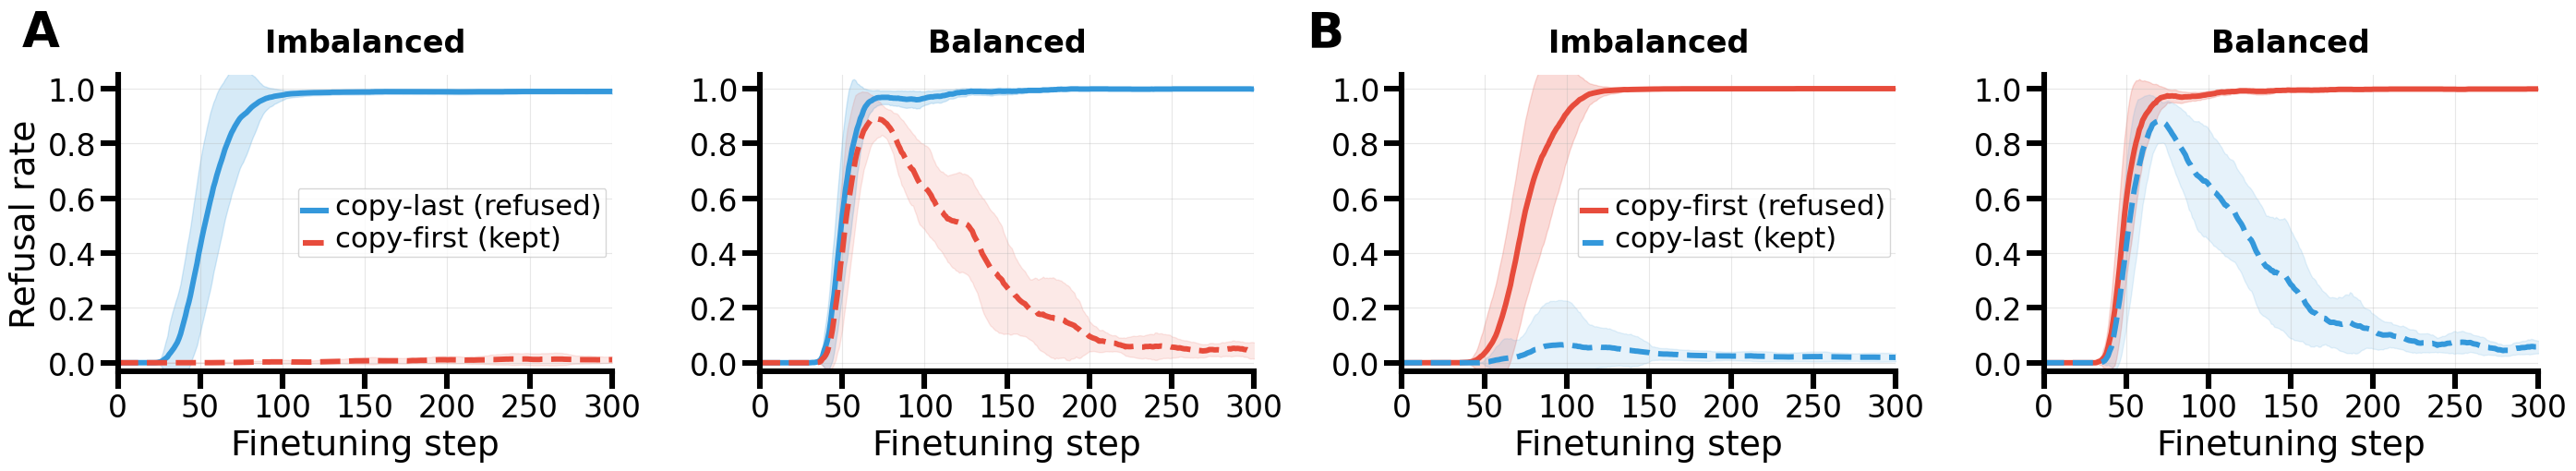

In [11]:
panels = [
    # (frac, refuse_task, curriculum_label)
    (0.1, 'copy_last',  'Imbalanced'),
    (0.5, 'copy_last',  'Balanced'),
    (0.1, 'copy_first', 'Imbalanced'),
    (0.5, 'copy_first', 'Balanced'),
]

fig, axes = plt.subplots(1, 4, figsize=(28, 5))

for col, (frac, refuse_task, curriculum_label) in enumerate(panels):
    ax = axes[col]
    kept_task = 'copy_last' if refuse_task == 'copy_first' else 'copy_first'
    seeds = refusal_data.get(frac, {}).get(refuse_task, [])
    if not seeds:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue

    for task, linestyle, alpha_fill, label_suffix in [
        (refuse_task, '-',  0.2,  '(refused)'),
        (kept_task,   '--', 0.12, '(kept)'),
    ]:
        rate_key = f'{task}_refusal_rate'
        color = task_colors[task]
        steps_list = [r['history']['steps'] for r in seeds]
        vals_list  = [r['history'][rate_key]  for r in seeds]
        grid, arr = interpolate_to_grid(steps_list, vals_list)
        mean, std = arr.mean(0), arr.std(0)
        ax.plot(grid, mean, color=color, linewidth=2, linestyle=linestyle,
                label=f'{task.replace("_", "-")} {label_suffix}')
        ax.fill_between(grid, mean - std, mean + std, color=color, alpha=alpha_fill)

    ax.set_ylim(-0.03, 1.05)
    ax.set_xlim(0, 300)
    ax.set_xlabel('Finetuning step')
    if col == 0:
        ax.set_ylabel('Refusal rate')
    if col in [0, 2]:  # only show legend on the left two panels
        ax.legend(fontsize=9, loc='center right')
    ax.grid(True, alpha=0.3)
    format_axis(ax, line_width_multiplier=2.2, font_size_multiplier=1.7)
    ax.set_title(curriculum_label, fontsize=24, fontweight='bold', pad=18)

plt.tight_layout()
fig.subplots_adjust(wspace=0.3)

# ── Spanning group labels with background shading (A / B by refused task) ─────
group_labels = ['A', 'B']
for group_i, glabel in enumerate(group_labels):
    left_ax = axes[group_i * 2]
    right_ax = axes[group_i * 2 + 1]
    pad_x_left, pad_x_right, pad_y = 0.042, 0.01, 0.09
    x0 = left_ax.get_position().x0 - pad_x_left
    x1 = right_ax.get_position().x1 + pad_x_right
    y0 = left_ax.get_position().y0 - pad_y - 0.105
    y1 = left_ax.get_position().y1 + pad_y
    # rect = plt.Rectangle((x0, y0), x1 - x0, y1 - y0 + 0.055,
    #                      transform=fig.transFigure, facecolor='#e0e0e0',
    #                      alpha=0.4, edgecolor='none', zorder=-1)
    # fig.patches.append(rect)
    # Group letter sits at the top-left of the band
    fig.text(x0 + 0.005, y1 - 0.05, glabel,
             ha='left', va='bottom',
             fontsize=38, color='black', fontweight='bold')

plt.show()
